In [1]:
# %conda install statsmodels
import pandas as pd, seaborn as sns, matplotlib.pyplot as plt, scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
url = "https://raw.githubusercontent.com/nkmwicz/data-for-students/refs/heads/main/imdb.csv"
df = pd.read_csv(url)


In [2]:
df.head(1)


,Unnamed: 0,Rank,Title,Genre,Description,Director,Actors,Year,Runtime (Minutes),Rating,...,Drama,Music,Biography,Romance,History,Crime,Western,War,Musical,Sport
0,0,1,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",A group of intergalactic criminals are forced ...,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.1,...,False,False,False,False,False,False,False,False,False,False


In [3]:

# for item in unique_items:
    # df[item] = df["Genre"].apply(lambda x: item_in_x)
    

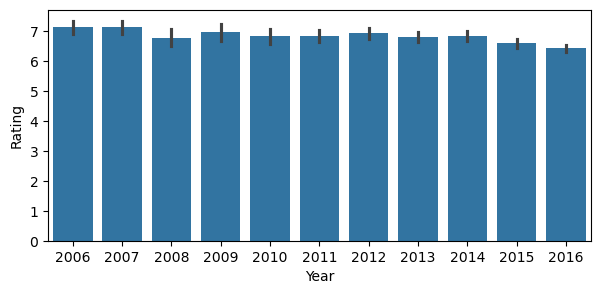

In [4]:
plt.figure(figsize=(7,3))
bar = sns.barplot(data=df, x="Year", y= "Rating")

In [5]:
years = sorted(df["Year"].unique())
samples = [df.loc[df["Year"] == y, "Rating"]for y in years]
f, p = stats.f_oneway(*samples)
dfb = len(years) - 1
dfw = len(df) - len(samples)
alpha = 0.05
cf = stats.f.ppf(1-alpha, dfb, dfw)
print(f"f:{f:.4f} crit_f: {cf:.4f}, p: {p:.4f}")

f:6.0455 crit_f: 1.8403, p: 0.0000


In [6]:
tukey = stats.tukey_hsd(*samples)
print(tukey)
print(years)

Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)     -0.009     1.000    -0.616     0.598
 (0 - 2)      0.340     0.779    -0.269     0.950
 (0 - 3)      0.164     0.999    -0.448     0.777
 (0 - 4)      0.298     0.870    -0.292     0.889
 (0 - 5)      0.287     0.889    -0.298     0.872
 (0 - 6)      0.200     0.991    -0.383     0.783
 (0 - 7)      0.313     0.751    -0.234     0.859
 (0 - 8)      0.287     0.827    -0.253     0.827
 (0 - 9)      0.523     0.048     0.002     1.043
 (0 - 10)      0.688     0.000     0.208     1.169
 (1 - 0)      0.009     1.000    -0.598     0.616
 (1 - 2)      0.349     0.690    -0.232     0.930
 (1 - 3)      0.173     0.997    -0.411     0.757
 (1 - 4)      0.307     0.799    -0.254     0.868
 (1 - 5)      0.296     0.825    -0.259     0.851
 (1 - 6)      0.209     0.980    -0.344     0.762
 (1 - 7)      0.322     0.635    -0.192     0.836
 (1 - 8)      0.296     0.728    -0.211    

In [7]:
tukey = pairwise_tukeyhsd(
    endog = df["Rating"], # numeric values
    groups = df["Year"],
    alpha = 0.05,
)
tukey.summary()

group1,group2,meandiff,p-adj,lower,upper,reject
2006,2007,0.009,1.0,-0.598,0.6159,False
2006,2008,-0.3404,0.7793,-0.95,0.2692,False
2006,2009,-0.1642,0.9987,-0.7765,0.4481,False
2006,2010,-0.2983,0.8695,-0.889,0.2923,False
2006,2011,-0.2869,0.8894,-0.8716,0.2978,False
2006,2012,-0.2,0.9905,-0.7828,0.3828,False
2006,2013,-0.3129,0.7512,-0.8594,0.2335,False
2006,2014,-0.2872,0.8273,-0.8273,0.2528,False
2006,2015,-0.5226,0.0481,-1.0432,-0.002,True
2006,2016,-0.6883,0.0002,-1.169,-0.2076,True


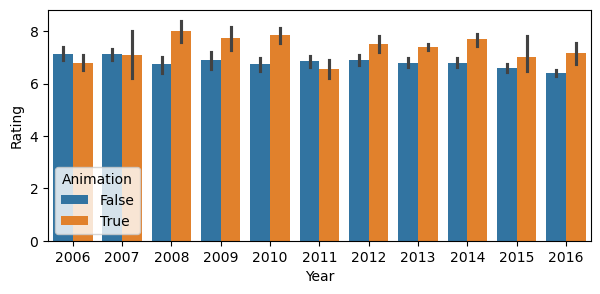

In [8]:

plt.figure(figsize=(7,3))
bar = sns.barplot(data=df, x="Year", y= "Rating", hue="Animation")

In [9]:

animated, non_animated = [
    df.loc[df["Animation"] == b, "Rating"] for b in [True, False]
    ]
t, p = stats.ttest_ind(animated, non_animated)
deg_f = len(animated) + len(non_animated) - 2
ct = stats.t.ppf(1-alpha/2, deg_f)
text = f"""t={t:.4f}
critical= {ct:.4f}
p= {p:.4f}
"""

Text(0.5, 0.1, 't=4.6113\ncritical= 1.9623\np= 0.0000\n')

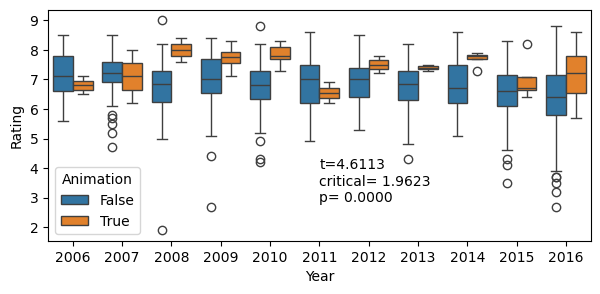

In [10]:

plt.figure(figsize=(7,3))
box = sns.boxplot(data=df, x="Year", y= "Rating", hue="Animation")
box.text(x=0.5, y=0.1, s=text, transform=box.transAxes)

In [11]:

# act, adv, scifi
# drama
# comedy, romance
# animation, adv, comedy 
# g1 = df.loc[(df["Action"] == True) & (df["Adventure"] == True)] -> exclusive
# g1 = df.loc[(df["Action"] == True) | (df["Adventure"] == True)] -> inclusive
g1 = df.loc[(df["Action"] == True) | (df["Adventure"] == True)]
s1 = {"l"}
s2 = {"l", "o"}
print(bool(s1 & s2))
s1 & s2

True


{'l'}

In [12]:
groups = [
    ["Action", "Adventure", "Sci-Fi"],
    ["Drama"], 
    ["Comedy", "Romance"],
    ["Animation", "Adventure", "Comedy"]
]
df["Genre"] = df ["Genre"].str.split(",")

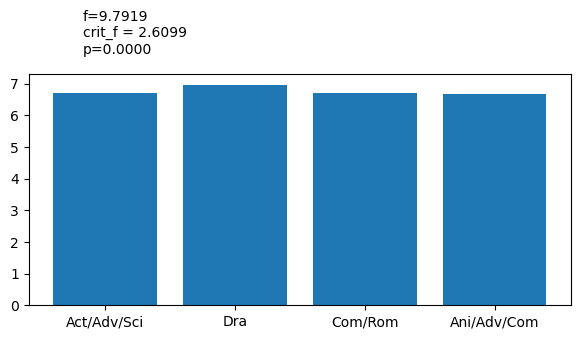

In [13]:

samples = [df.loc[df["Genre"].apply(lambda x: bool(set(x) & set(g))), "Rating"] for g in groups ]
f, p = stats.f_oneway(*samples)
dfb = len(samples) - 1
dfw = sum([len(s) for s in samples ]) - len(samples)
cf = stats.f.ppf(1-alpha, dfb, dfw)
text = f"""f={f:.4f}
crit_f = {cf:.4f}
p={p:.4f}
"""

heights = [s.mean() for s in samples]
cols = ["/".join([item[:3]for item in g]) for g in groups]
plt.figure(figsize=(7,3))
plt.bar(x=cols, height=heights)
plt.text(x=0.1, y=1.02, s=text, transform= plt.gca().transAxes)
plt.show()